# Data Import and Description

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# STEP 1: DATA OVERVIEW & CLEANING
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.columns = ['Temp']

print("--- Data Structure & Null Values ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Data Structure & Null Values ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB
None

--- Descriptive Statistics ---
              Temp
count  3650.000000
mean     11.177753
std       4.071837
min       0.000000
25%       8.300000
50%      11.000000
75%      14.000000
max      26.300000


## Time-Series Visualization

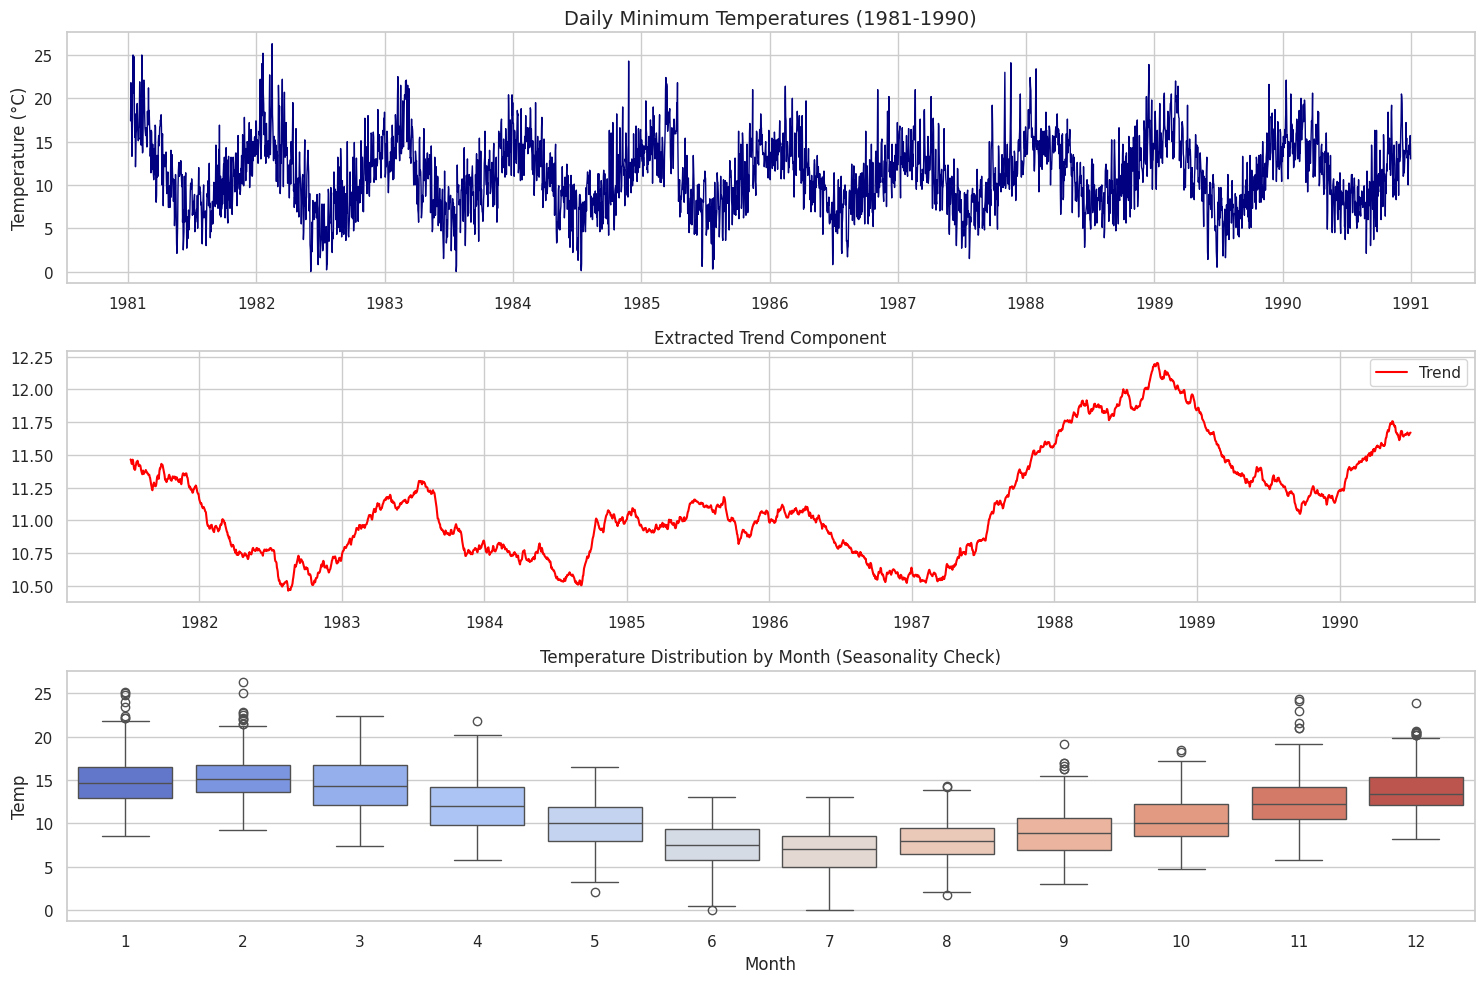

In [ ]:

# TIME-SERIES VISUALIZATION
plt.figure(figsize=(15, 10))

# 1. Main Time Series Plot
plt.subplot(3, 1, 1)
plt.plot(df['Temp'], color='navy', lw=1)
plt.title("Daily Minimum Temperatures (1981-1990)", fontsize=14)
plt.ylabel("Temperature (°C)")

# 2. Seasonal Decomposition (Trend, Seasonality, Residuals)
# Using period=365 for annual seasonality
result = seasonal_decompose(df['Temp'], model='additive', period=365)
plt.subplot(3, 1, 2)
plt.plot(result.trend, color='red', label='Trend')
plt.title("Extracted Trend Component", fontsize=12)
plt.legend()

# 3. Monthly Distribution (Boxplot to show seasonality)
plt.subplot(3, 1, 3)
df['Month'] = df.index.month
sns.boxplot(x='Month', y='Temp', data=df, palette="coolwarm")
plt.title("Temperature Distribution by Month (Seasonality Check)", fontsize=12)

plt.tight_layout()
plt.show()



## Statistical Assumption Testing


--- Statistical Assumption Testing ---


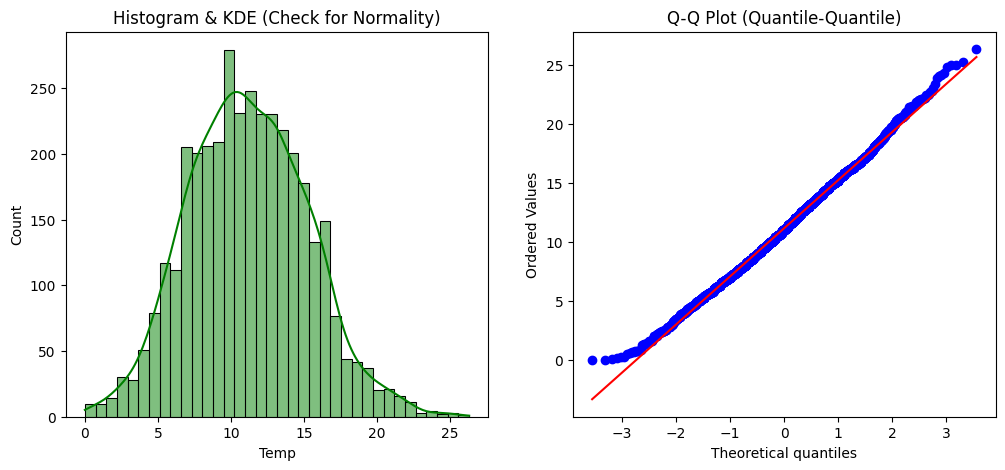

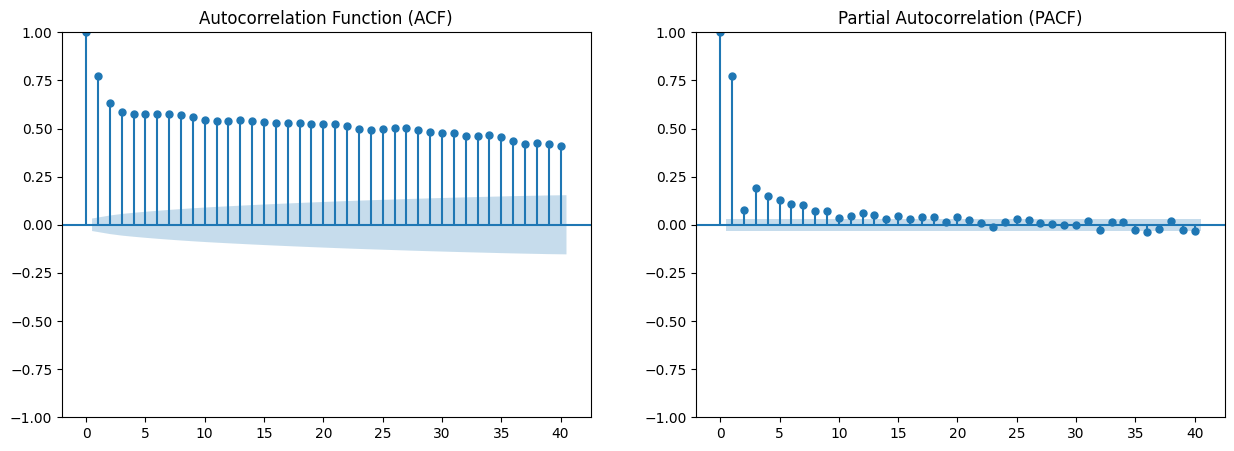

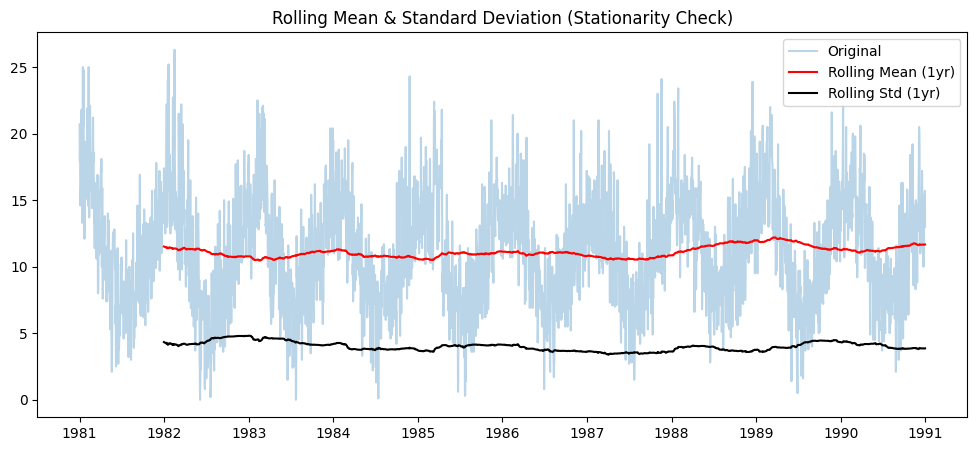

In [ ]:
# STATISTICAL ASSUMPTION TESTING
print("\n--- Statistical Assumption Testing ---")

# 1. Normality Check (Important for OLS vs GLM)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Temp'], kde=True, color='green')
plt.title("Histogram & KDE (Check for Normality)")

plt.subplot(1, 2, 2)
stats.probplot(df['Temp'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Quantile-Quantile)")
plt.show()

# 2. Autocorrelation Analysis (Identification of AR/MA terms)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['Temp'], lags=40, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(df['Temp'], lags=40, ax=ax[1])
ax[1].set_title("Partial Autocorrelation (PACF)")
plt.show()

# 3. Rolling Statistics (Checking for Stationarity visually)
rolling_mean = df['Temp'].rolling(window=365).mean()
rolling_std = df['Temp'].rolling(window=365).std()

plt.figure(figsize=(12, 5))
plt.plot(df['Temp'], alpha=0.3, label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (1yr)')
plt.plot(rolling_std, color='black', label='Rolling Std (1yr)')
plt.title("Rolling Mean & Standard Deviation (Stationarity Check)")
plt.legend()
plt.show()


## Feature Lags

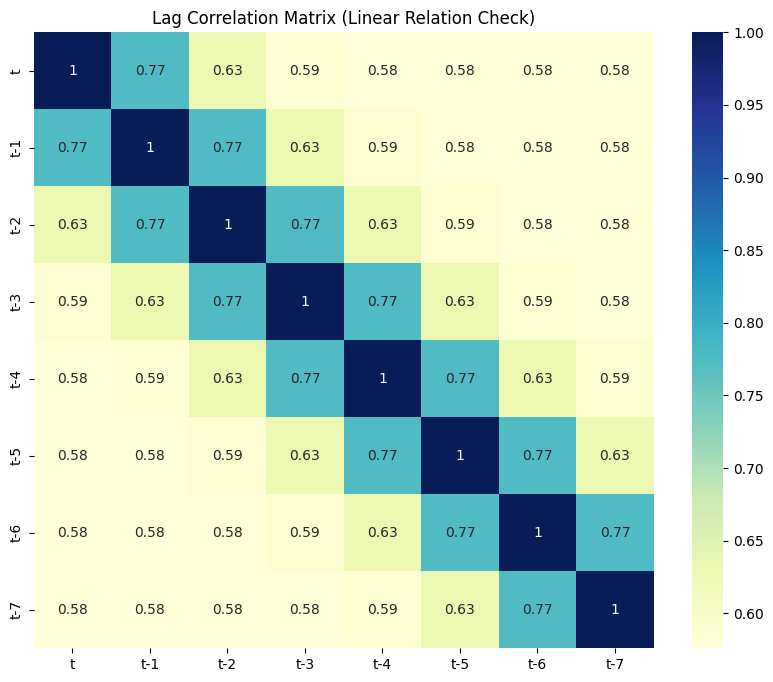

In [ ]:
# STEP 4: CORRELATION & FEATURE LAGS
# Creating a lag matrix to see which previous days predict today best
lag_df = pd.concat([df['Temp'].shift(i) for i in range(8)], axis=1)
lag_df.columns = ['t', 't-1', 't-2', 't-3', 't-4', 't-5', 't-6', 't-7']

plt.figure(figsize=(10, 8))
sns.heatmap(lag_df.corr(), annot=True, cmap='YlGnBu')
plt.title("Lag Correlation Matrix (Linear Relation Check)")
plt.show()

## Correlation

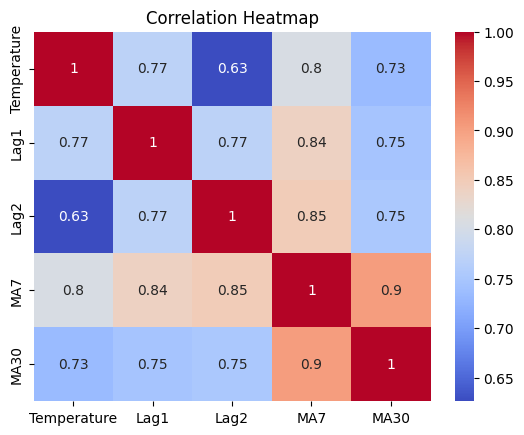

In [ ]:
# Correlation
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

data.rename(columns={'Temp': 'Temperature'}, inplace=True)

data['Lag1'] = data['Temperature'].shift(1)
data['Lag2'] = data['Temperature'].shift(2)
data['MA7'] = data['Temperature'].rolling(7).mean()
data['MA30'] = data['Temperature'].rolling(30).mean()

data.dropna(inplace=True)
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Model Traning

## Feature Engineering and Imports

In [ ]:
#  Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

from tqdm import tqdm

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Data Loading & Feature Engineering
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.columns = ['Temp']

# Combined Features (NO DUPLICATION)
df['Lag1'] = df['Temp'].shift(1)
df['Lag7'] = df['Temp'].shift(7)
df['Rolling_7'] = df['Temp'].shift(1).rolling(window=7).mean()
df['DayOfYear'] = df.index.dayofyear

df.dropna(inplace=True)

# Features
X = df[['Lag1', 'Lag7', 'Rolling_7', 'DayOfYear']]
y = df['Temp']

# Train-Test Split (balanced)
split = int(len(df) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Data Ready | Train: {len(X_train)}, Test: {len(X_test)}")


Data Ready | Train: 3278, Test: 365


## OLS + VIF + Hypothesis Testing

In [ ]:
# OLS + VIF + Hypothesis Testing
X_train_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_ols).fit()

print("\n--- OLS SUMMARY ---")
print(ols_model.summary())

print("\n--- P-VALUES ---")
print(ols_model.pvalues)

# VIF
def calc_vif(X_df):
    X_vif = sm.add_constant(X_df)
    return pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })

print("\n--- VIF ---")
print(calc_vif(X_train))


--- OLS SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                   Temp   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     1422.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:16:06   Log-Likelihood:                -7613.8
No. Observations:                3278   AIC:                         1.524e+04
Df Residuals:                    3273   BIC:                         1.527e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2093      0.19

## REGRESSION MODELS

In [ ]:
# REGRESSION MODELS
print("\n--- Regression Models ---")

# Simple Linear Model
slr = LinearRegression().fit(X_train[['Lag1']], y_train)
p_slr = slr.predict(X_test[['Lag1']])

# Multiple Linear Model
mlr = LinearRegression().fit(X_train, y_train)
p_mlr = mlr.predict(X_test)

# Polynomial Model
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_reg = LinearRegression().fit(X_train_poly, y_train)
p_poly = poly_reg.predict(X_test_poly)

# GLM (Gamma Model)
glm_model = sm.GLM(
    y_train,
    X_train_ols,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
p_glm = glm_model.predict(sm.add_constant(X_test))

# Lasso Model
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
p_lasso = lasso.predict(X_test)

# OLS predictions
p_ols = ols_model.predict(sm.add_constant(X_test))


--- Regression Models ---


## STATIONARITY (ADF)

In [ ]:
# STATIONARITY (ADF)
adf_res = adfuller(y_train)
print(f"\nADF Statistic: {adf_res[0]:.4f}, p-value: {adf_res[1]:.4f}")



ADF Statistic: -4.2852, p-value: 0.0005


## TIME SERIES (ARIMA + SARIMA with tqdm)

In [ ]:
# TIME SERIES (ARIMA + SARIMA with tqdm)
print("\n--- Time Series Walk-Forward ---")

history = list(y_train)
p_arima, p_sarima = [], []

for t in tqdm(range(len(y_test))):
    # ARIMA
    model_arima = ARIMA(history, order=(5,1,0)).fit()
    p_arima.append(model_arima.forecast()[0])

    # SARIMA
    model_sarima = SARIMAX(history, order=(1,1,1), seasonal_order=(1,1,0,7)).fit(disp=False)
    p_sarima.append(model_sarima.forecast()[0])

    history.append(y_test.iloc[t])


--- Time Series Walk-Forward ---


100%|██████████| 365/365 [29:17<00:00,  4.82s/it]


## METRICS COMPARISON

In [ ]:
# METRICS COMPARISON
models = {
    "OLS": p_ols,
    "Simple Linear": p_slr,
    "Multiple Linear": p_mlr,
    "Polynomial": p_poly,
    "GLM": p_glm,
    "Lasso": p_lasso,
    "ARIMA": p_arima,
    "SARIMA": p_sarima
}

results = []
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results.append({
        "Model": name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

df_results = pd.DataFrame(results).sort_values(by="RMSE")

print("\n--- FINAL MODEL RANKING ---")
print(df_results)



--- FINAL MODEL RANKING ---
             Model    RMSE     MAE
3       Polynomial  2.2787  1.7644
0              OLS  2.3231  1.7959
2  Multiple Linear  2.3231  1.7959
5            Lasso  2.3233  1.7970
6            ARIMA  2.3361  1.7989
4              GLM  2.3956  1.8656
1    Simple Linear  2.4368  1.9352
7           SARIMA  2.7349  2.1343


## Visualization

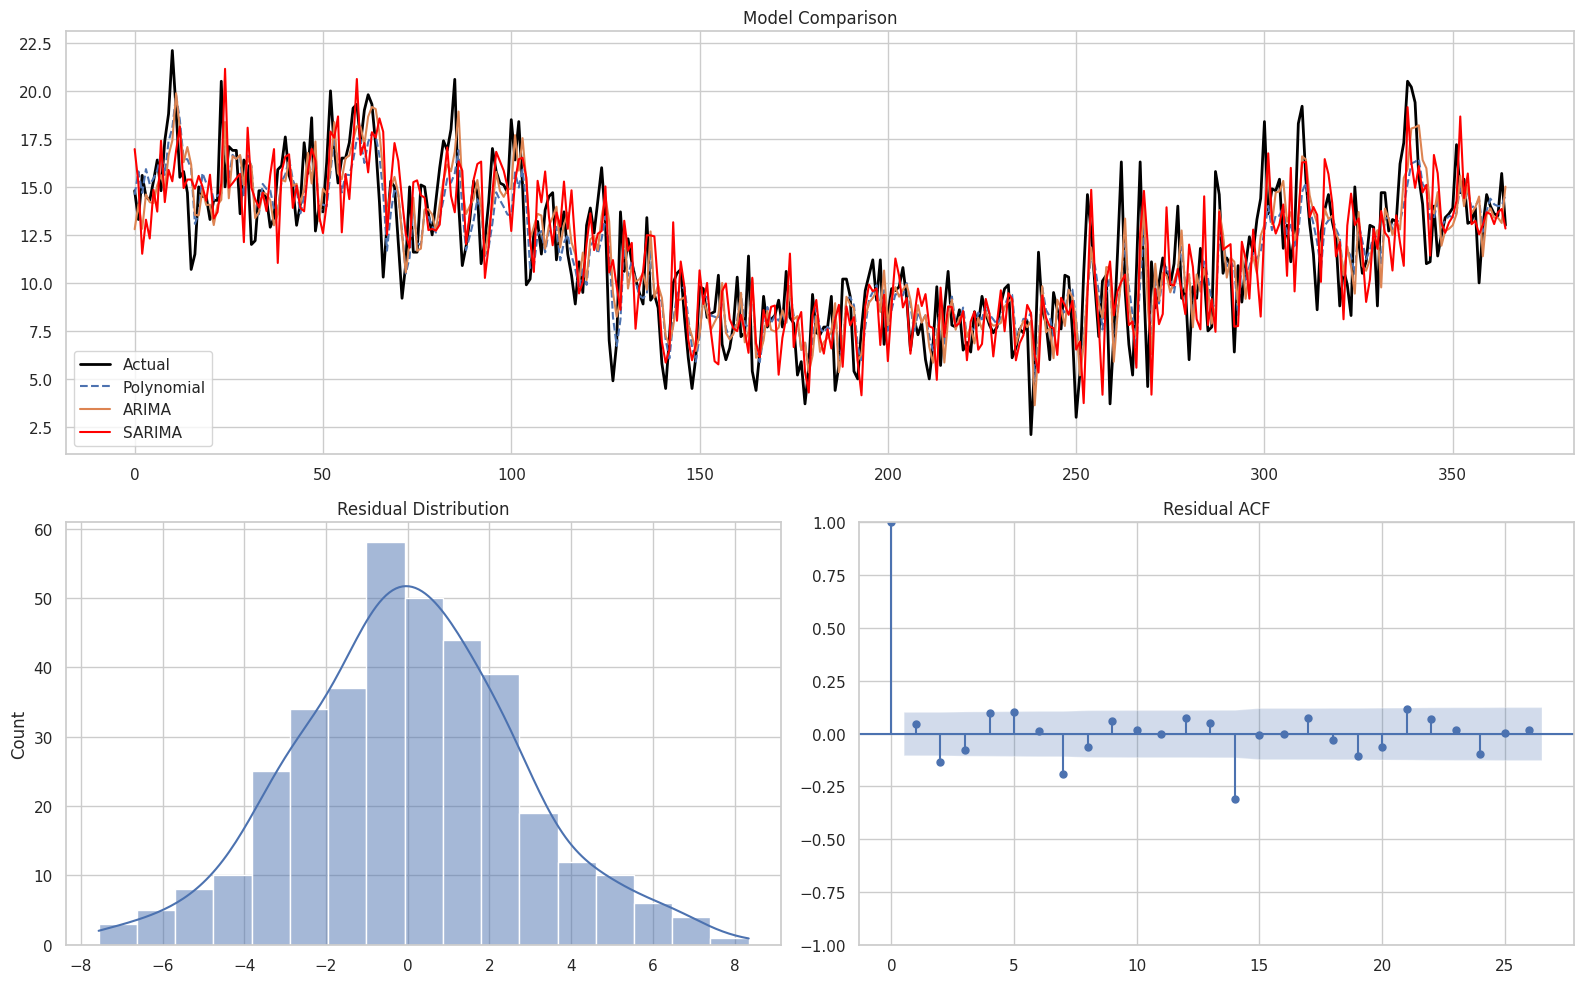

In [ ]:
# VISUALIZATION
plt.figure(figsize=(16, 10))

# 🔹 Main Comparison Plot
plt.subplot(2, 1, 1)
plt.plot(y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(p_poly, '--', label='Polynomial')
plt.plot(p_arima, label='ARIMA')
plt.plot(p_sarima, label='SARIMA', color='red')
plt.legend()
plt.title("Model Comparison")

# 🔹 Residual Analysis (SARIMA)
residuals = y_test.values - p_sarima

plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

plt.subplot(2, 2, 4)
plot_acf(residuals, ax=plt.gca())
plt.title("Residual ACF")

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Model Performance Comparison ---")
print(df_results)


--- Model Performance Comparison ---
             Model    RMSE     MAE
3       Polynomial  2.2787  1.7644
0              OLS  2.3231  1.7959
2  Multiple Linear  2.3231  1.7959
5            Lasso  2.3233  1.7970
6            ARIMA  2.3361  1.7989
4              GLM  2.3956  1.8656
1    Simple Linear  2.4368  1.9352
7           SARIMA  2.7349  2.1343


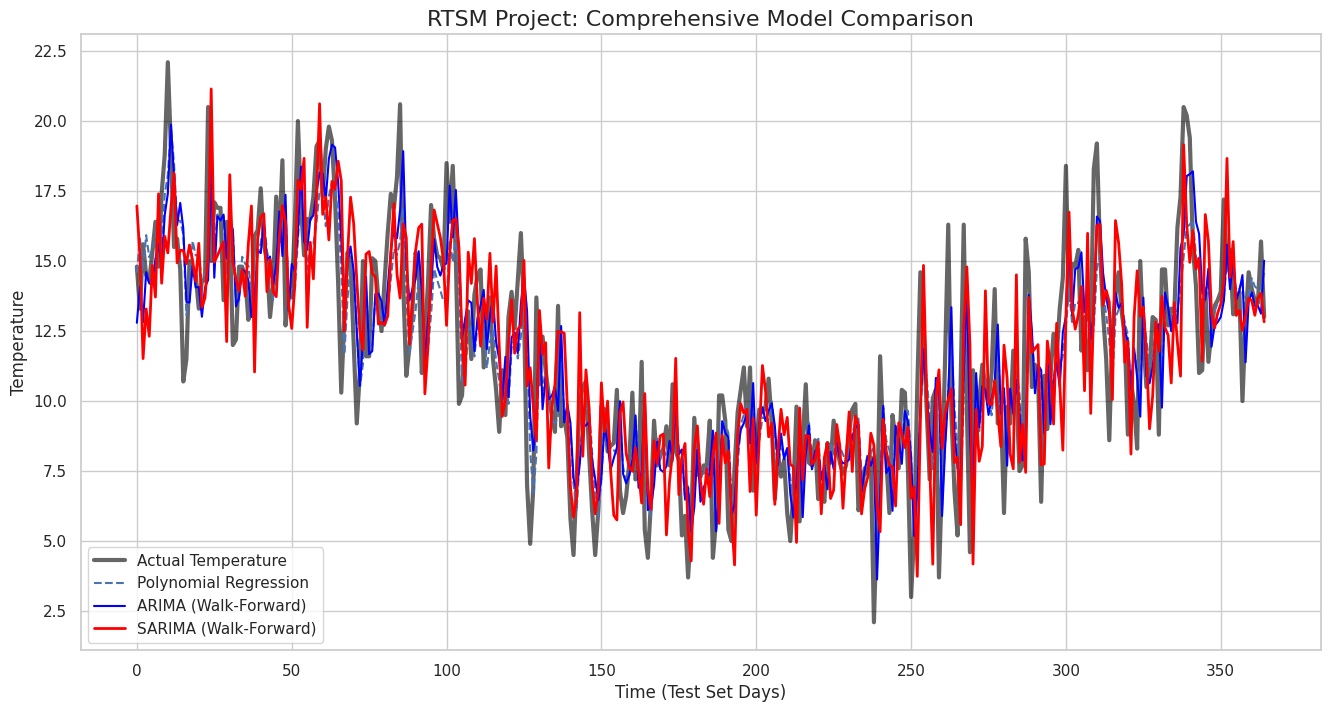

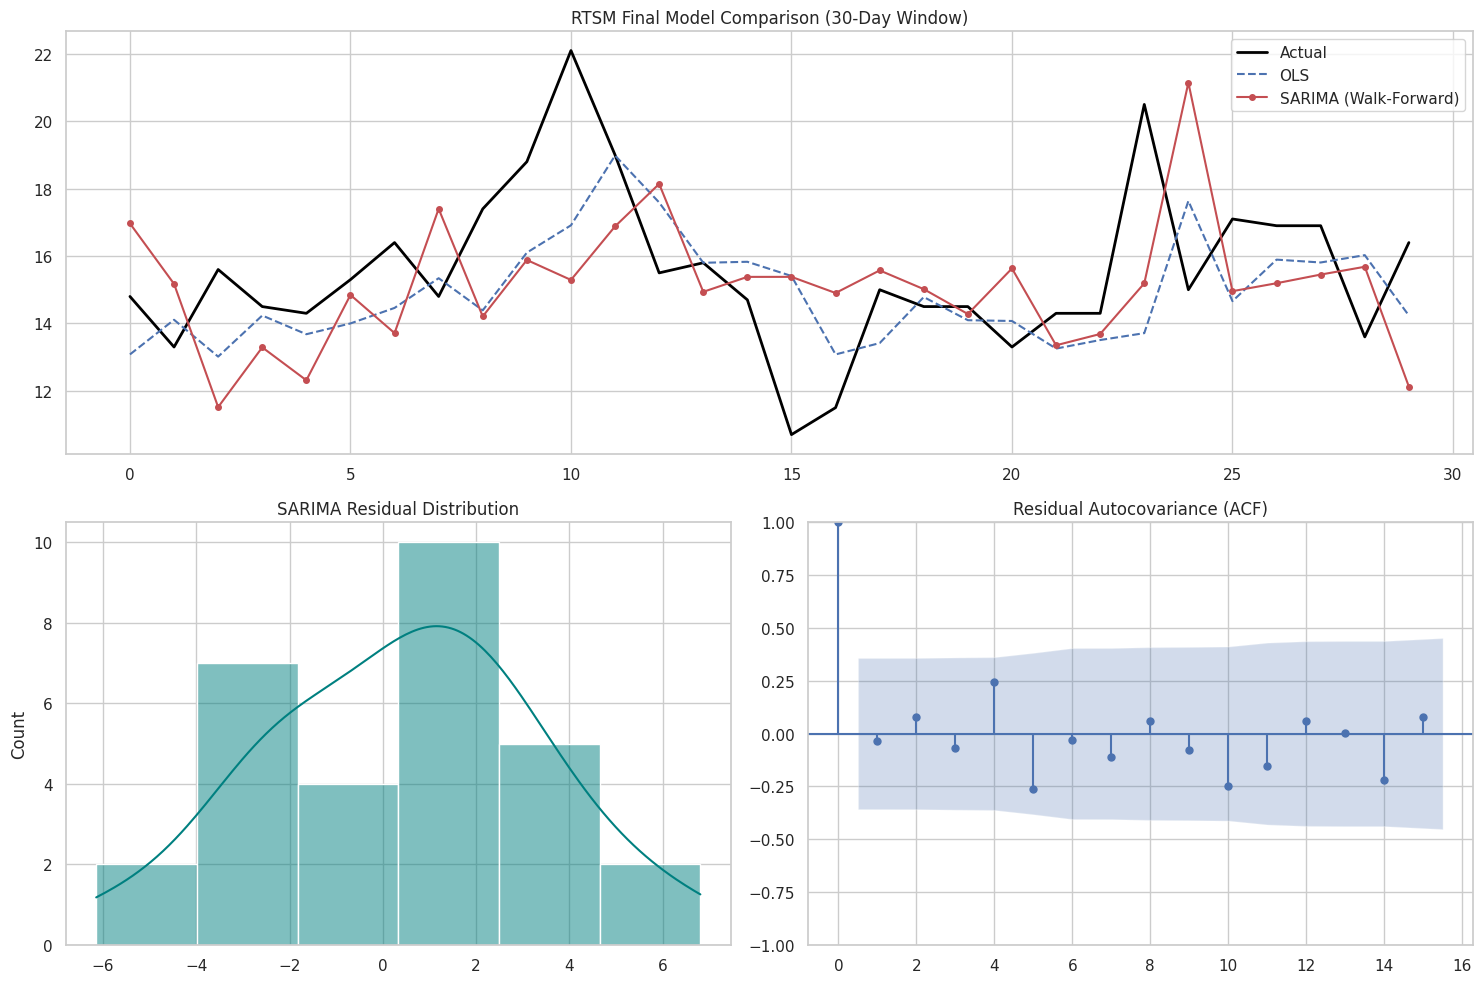

In [ ]:
# FULL TEST SET COMPARISON
plt.figure(figsize=(16, 8))
plt.plot(y_test.values, label='Actual Temperature', color='black', linewidth=3, alpha=0.6)
plt.plot(p_poly, label='Polynomial Regression', linestyle='--')
plt.plot(p_arima, label='ARIMA (Walk-Forward)', color='blue')
plt.plot(p_sarima, label='SARIMA (Walk-Forward)', color='red', linewidth=2)

plt.title("RTSM Project: Comprehensive Model Comparison", fontsize=16)
plt.xlabel("Time (Test Set Days)")
plt.ylabel("Temperature")
plt.legend()
plt.show()


# MULTI-PLOT (OLS + SARIMA + Residuals)
plt.figure(figsize=(15, 10))

# Subplot 1: Forecast Comparison
plt.subplot(2, 1, 1)
plt.plot(y_test.values[:30], label='Actual', color='black', linewidth=2)
plt.plot(p_ols.values[:30], '--', label='OLS')
plt.plot(p_sarima[:30], 'r-o', label='SARIMA (Walk-Forward)', markersize=4)
plt.title("RTSM Final Model Comparison (30-Day Window)")
plt.legend()

# Subplot 2: Residual Analysis
residuals = y_test.values[:30] - np.array(p_sarima[:30])

plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True, color='teal')
plt.title("SARIMA Residual Distribution")

# Subplot 3: ACF
plt.subplot(2, 2, 4)
plot_acf(residuals, ax=plt.gca())
plt.title("Residual Autocovariance (ACF)")

plt.tight_layout()
plt.show()


# SHORT-TERM DETAILED COMPARISON (GLM + OLS + SARIMA)
y_test_short = y_test[:30]

y_pred_ols_short = ols_model.predict(sm.add_constant(X_test[:30]))
y_pred_glm_short = glm_model.predict(sm.add_constant(X_test[:30]))
y_pred_sarima_short = p_sarima[:30]



--- Final Model Comparison (First 30 Days) ---
GLM RMSE:   2.6640
OLS RMSE:   2.3587
SARIMA RMSE:2.9513


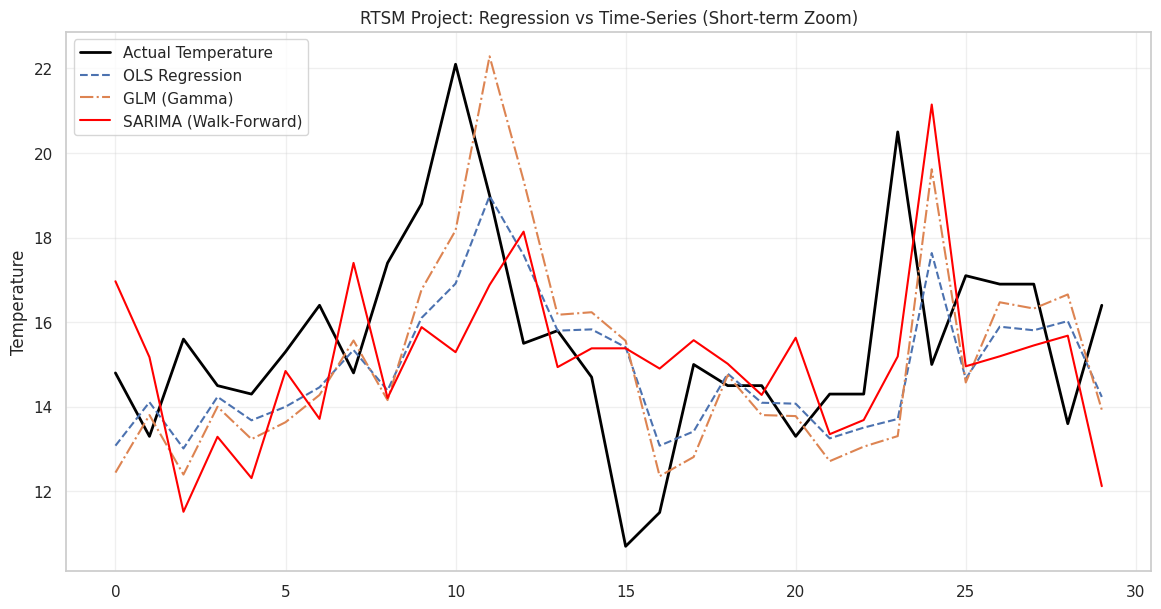

In [ ]:
print("\n--- Final Model Comparison (First 30 Days) ---")
print(f"GLM RMSE:   {np.sqrt(mean_squared_error(y_test_short, y_pred_glm_short)):.4f}")
print(f"OLS RMSE:   {np.sqrt(mean_squared_error(y_test_short, y_pred_ols_short)):.4f}")
print(f"SARIMA RMSE:{np.sqrt(mean_squared_error(y_test_short, y_pred_sarima_short)):.4f}")

plt.figure(figsize=(14, 7))
plt.plot(y_test_short.values, label='Actual Temperature', color='black', lw=2)
plt.plot(y_pred_ols_short.values, label='OLS Regression', linestyle='--')
plt.plot(y_pred_glm_short.values, label='GLM (Gamma)', linestyle='-.')
plt.plot(y_pred_sarima_short, label='SARIMA (Walk-Forward)', color='red')

plt.title("RTSM Project: Regression vs Time-Series (Short-term Zoom)")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analysis

## Table

In [ ]:
#  COMPREHENSIVE PERFORMANCE TABLE
from sklearn.metrics import r2_score

X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

results = []
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R-Squared": r2
    })

df_results = pd.DataFrame(results).sort_values(by="RMSE")

print("\n")
print("FINAL MODEL RANKING (REPORT READY)")
print("\n")
print(df_results.to_string(index=False))

best_model_name = df_results.iloc[0]['Model']
print(f"\nCONCLUSION: The best performing model is {best_model_name}")
print("\n")




FINAL MODEL RANKING (REPORT READY)


          Model     RMSE      MAE  R-Squared
     Polynomial 2.278669 1.764412   0.650844
            OLS 2.323105 1.795852   0.637094
Multiple Linear 2.323105 1.795852   0.637094
          Lasso 2.323327 1.796994   0.637024
          ARIMA 2.336087 1.798869   0.633026
            GLM 2.395642 1.865575   0.614077
  Simple Linear 2.436789 1.935153   0.600706
         SARIMA 2.734866 2.134342   0.497045

CONCLUSION: The best performing model is Polynomial




In [ ]:
#  FINAL TABLE
print("\n")
print("FINAL RTSM PERFORMANCE TABLE")
print("\n")

df_results['Rank'] = range(1, len(df_results) + 1)

print(df_results[['Rank', 'Model', 'RMSE', 'MAE']].to_string(index=False))

print("\n")
print(f"BEST MODEL: {best_model_name}")
print("\n")



FINAL RTSM PERFORMANCE TABLE


 Rank           Model     RMSE      MAE
    1      Polynomial 2.278669 1.764412
    2             OLS 2.323105 1.795852
    3 Multiple Linear 2.323105 1.795852
    4           Lasso 2.323327 1.796994
    5           ARIMA 2.336087 1.798869
    6             GLM 2.395642 1.865575
    7   Simple Linear 2.436789 1.935153
    8          SARIMA 2.734866 2.134342


BEST MODEL: Polynomial




## Best Model Plots

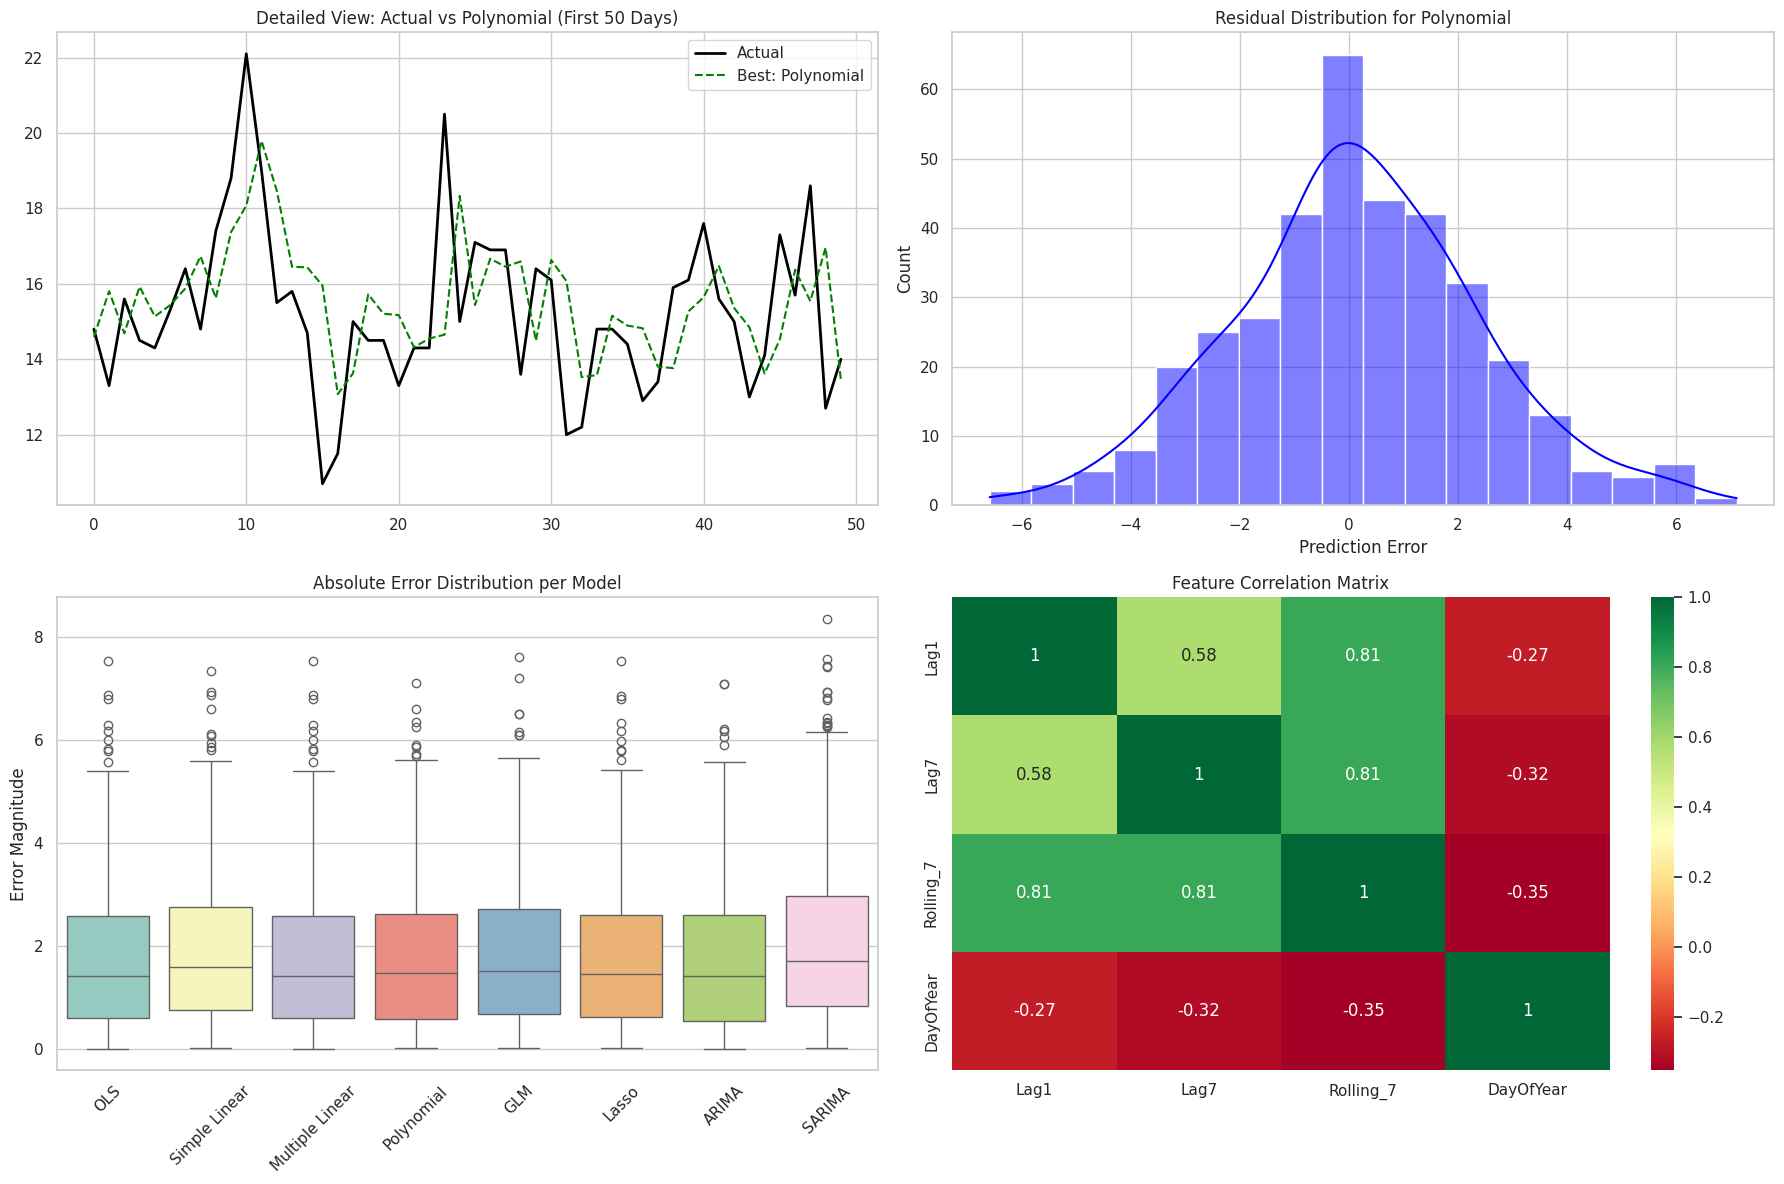



HYPOTHESIS TESTING & STATISTICAL SIGNIFICANCE


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2093      0.199      6.080      0.000       0.819       1.599
Lag1           0.5345      0.018     29.171      0.000       0.499       0.570
Lag7           0.0658      0.018      3.588      0.000       0.030       0.102
Rolling_7      0.2953      0.031      9.639      0.000       0.235       0.355
DayOfYear     -0.0003      0.000     -0.639      0.523      -0.001       0.001


In [ ]:
# POST-TRAINING REPORT (RUN AFTER MODELS)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller

#  VISUALIZATION SUITE
fig = plt.figure(figsize=(18, 12))

# Plot 1: Best vs Actual
plt.subplot(2, 2, 1)
plt.plot(y_test.values[:50], label='Actual', color='black', lw=2)
plt.plot(models[best_model_name][:50], label=f'Best: {best_model_name}', color='green', linestyle='--')
plt.title(f"Detailed View: Actual vs {best_model_name} (First 50 Days)")
plt.legend()

# Plot 2: Residual Distribution
plt.subplot(2, 2, 2)
best_residuals = y_test.values - models[best_model_name]
sns.histplot(best_residuals, kde=True, color='blue')
plt.title(f"Residual Distribution for {best_model_name}")
plt.xlabel("Prediction Error")

# Plot 3: Boxplot of Errors
plt.subplot(2, 2, 3)
error_data = pd.DataFrame({
    name: np.abs(y_test.values - pred)
    for name, pred in models.items()
})
sns.boxplot(data=error_data, palette="Set3")
plt.xticks(rotation=45)
plt.title("Absolute Error Distribution per Model")
plt.ylabel("Error Magnitude")

# Plot 4: Feature Correlation (Multicollinearity)
plt.subplot(2, 2, 4)
sns.heatmap(X_train.corr(), annot=True, cmap='RdYlGn')
plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# HYPOTHESIS TESTING (OLS)
print("\n")
print("HYPOTHESIS TESTING & STATISTICAL SIGNIFICANCE")
print("\n")

X_train_sm = sm.add_constant(X_train)
ols_summary = sm.OLS(y_train, X_train_sm).fit()
print(ols_summary.summary().tables[1])



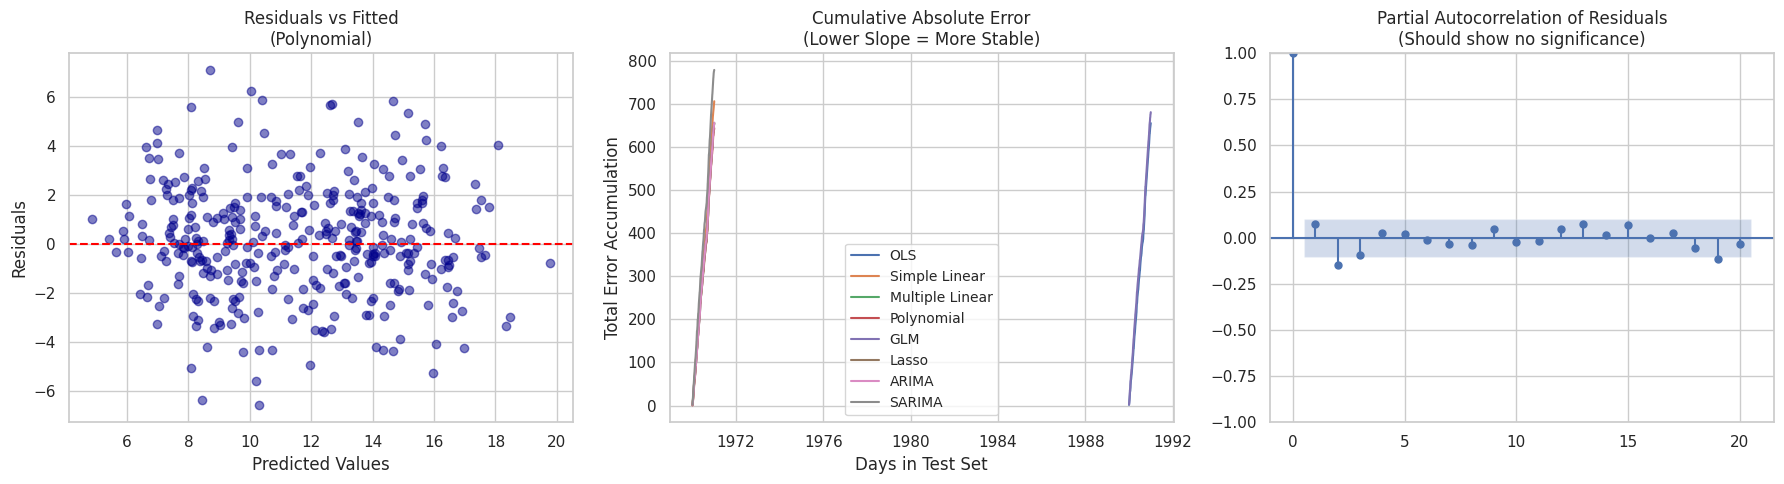

In [ ]:
# ADVANCED DIAGNOSTIC PLOTS
plt.figure(figsize=(18, 5))

# Plot 1: Residuals vs Fitted (Checking for Constant Variance/Heteroscedasticity)
plt.subplot(1, 3, 1)
best_preds = models[best_model_name]
plt.scatter(best_preds, best_residuals, alpha=0.5, color='darkblue')
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Residuals vs Fitted\n({best_model_name})")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Plot 2: Cumulative Absolute Error (Model Stability over Time)
plt.subplot(1, 3, 2)
for name, pred in models.items():
    cum_error = np.cumsum(np.abs(y_test.values - pred))
    plt.plot(cum_error, label=name)
plt.title("Cumulative Absolute Error\n(Lower Slope = More Stable)")
plt.xlabel("Days in Test Set")
plt.ylabel("Total Error Accumulation")
plt.legend(fontsize='small')

# Plot 3: PACF of Best Model Residuals (Linear Process Check)
plt.subplot(1, 3, 3)
plot_pacf(best_residuals, ax=plt.gca(), lags=20)
plt.title("Partial Autocorrelation of Residuals\n(Should show no significance)")

plt.tight_layout()
plt.show()


## INDIVIDUAL MODEL VISUALIZATION



VISUALIZING MODEL: OLS




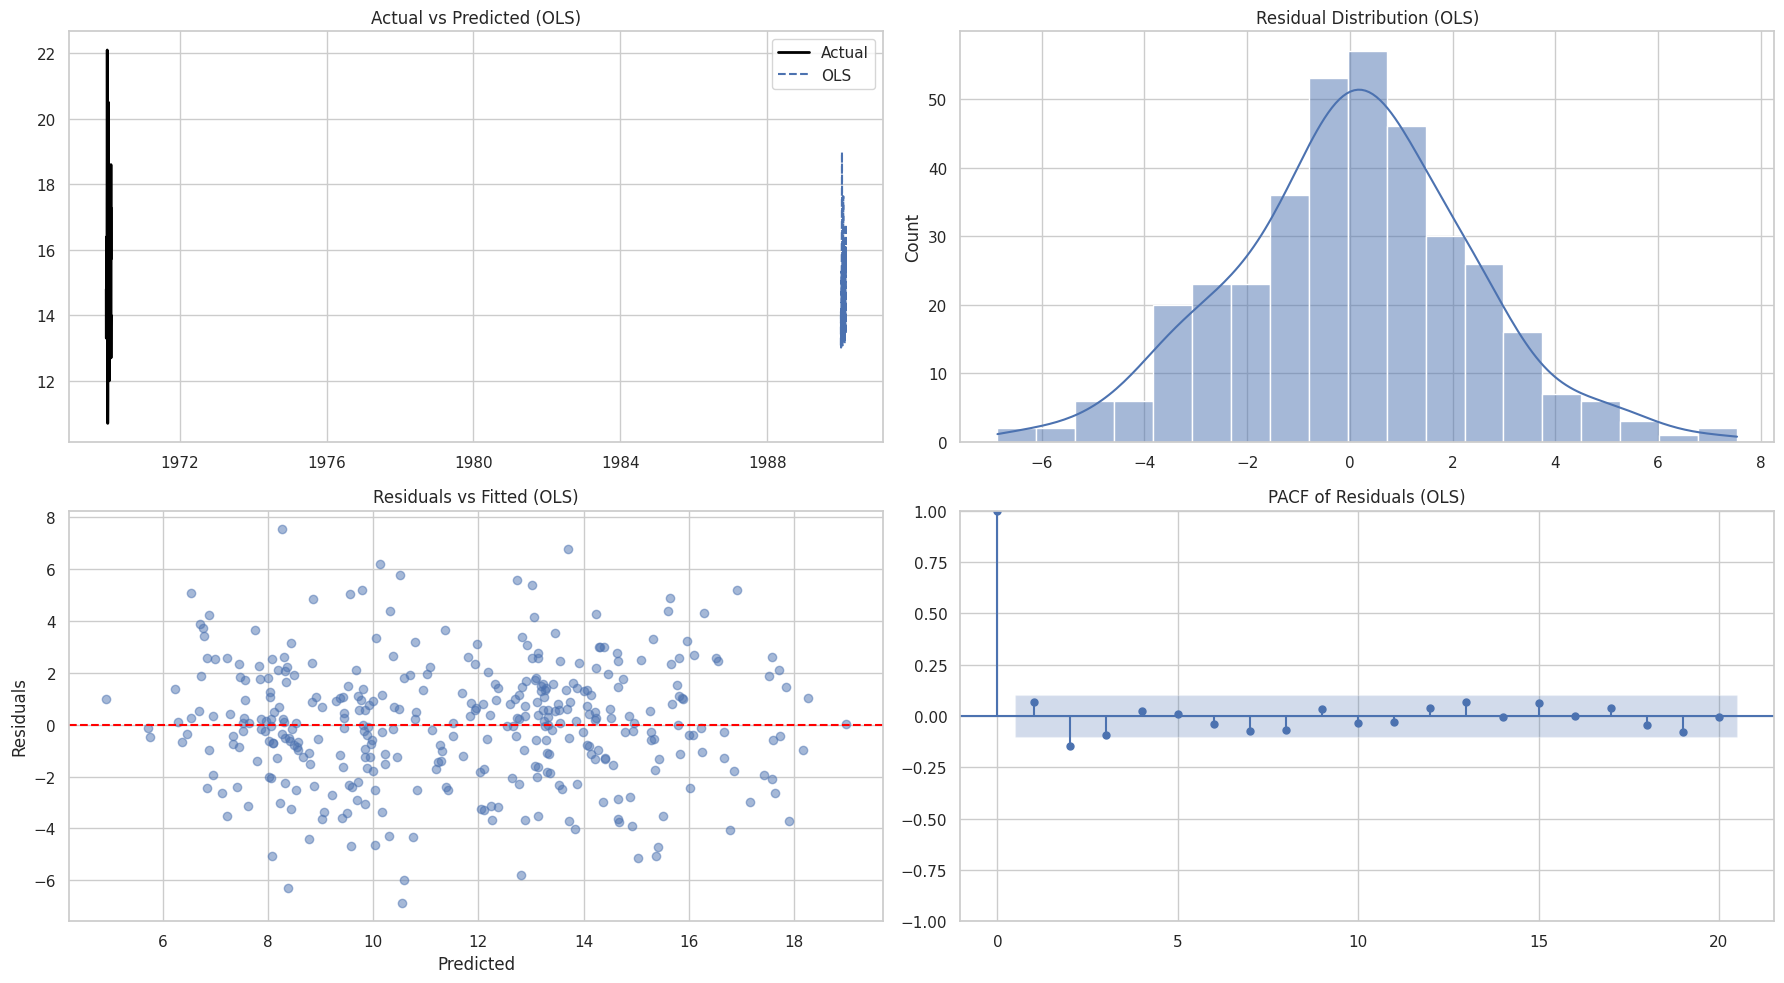



VISUALIZING MODEL: Simple Linear




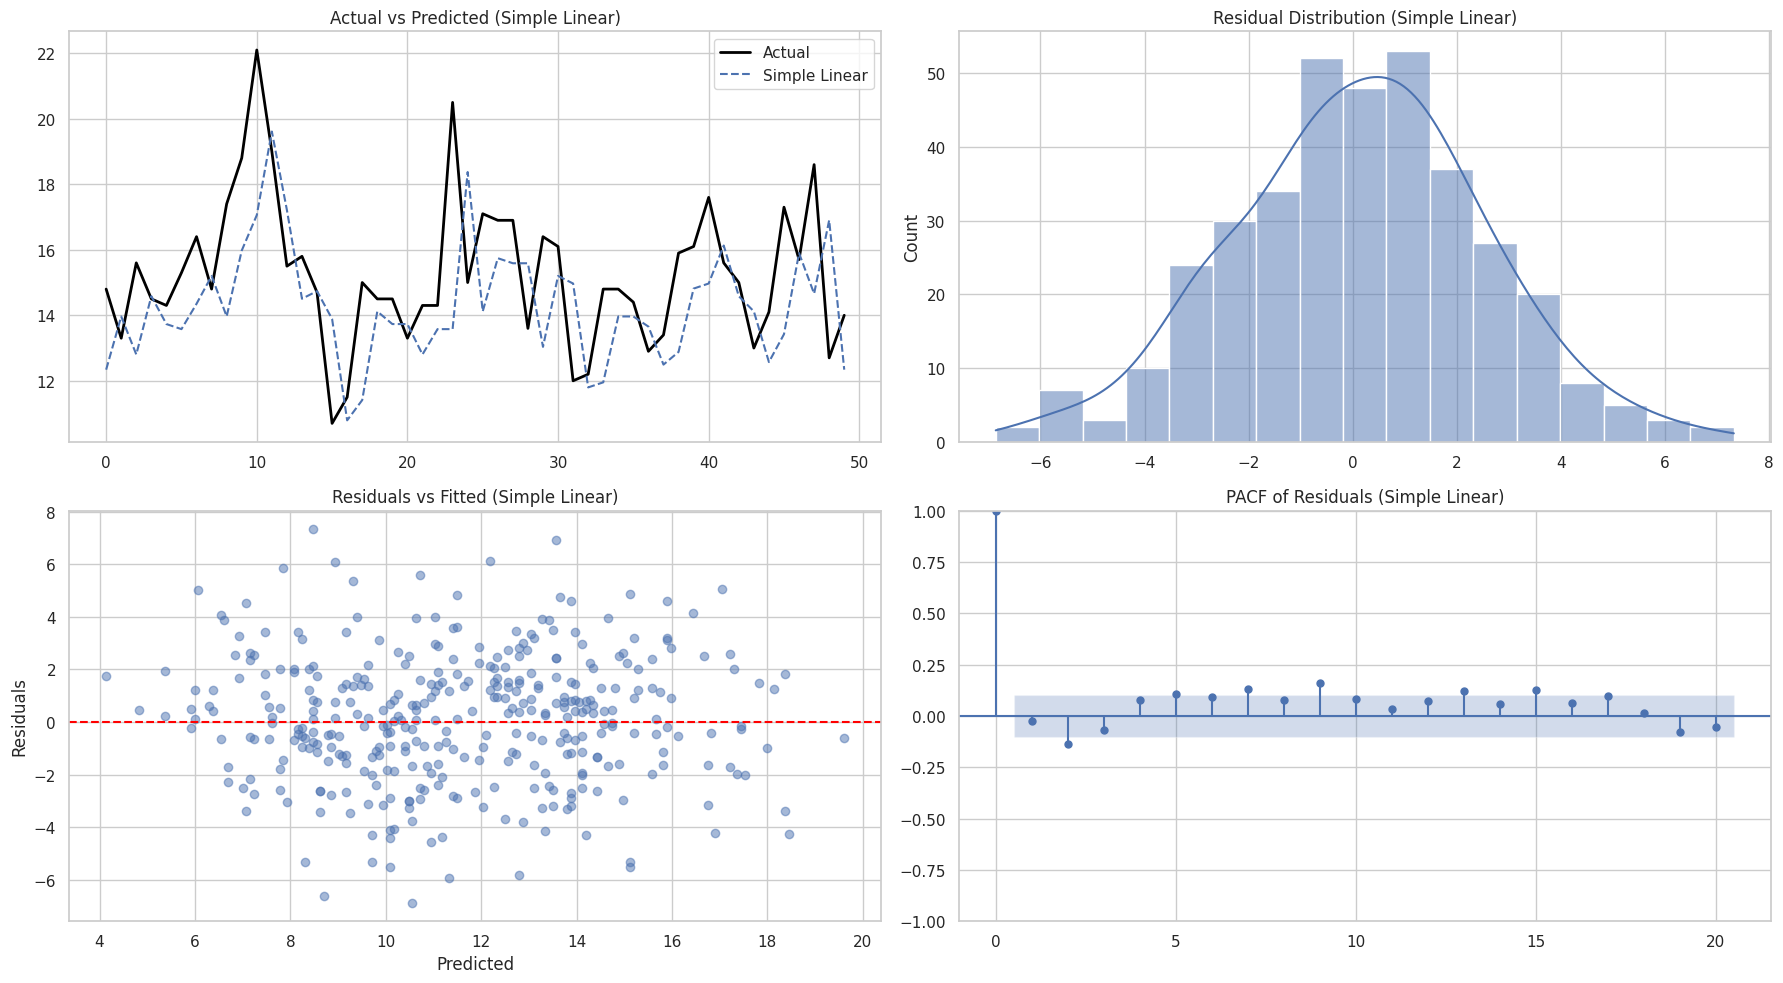



VISUALIZING MODEL: Multiple Linear




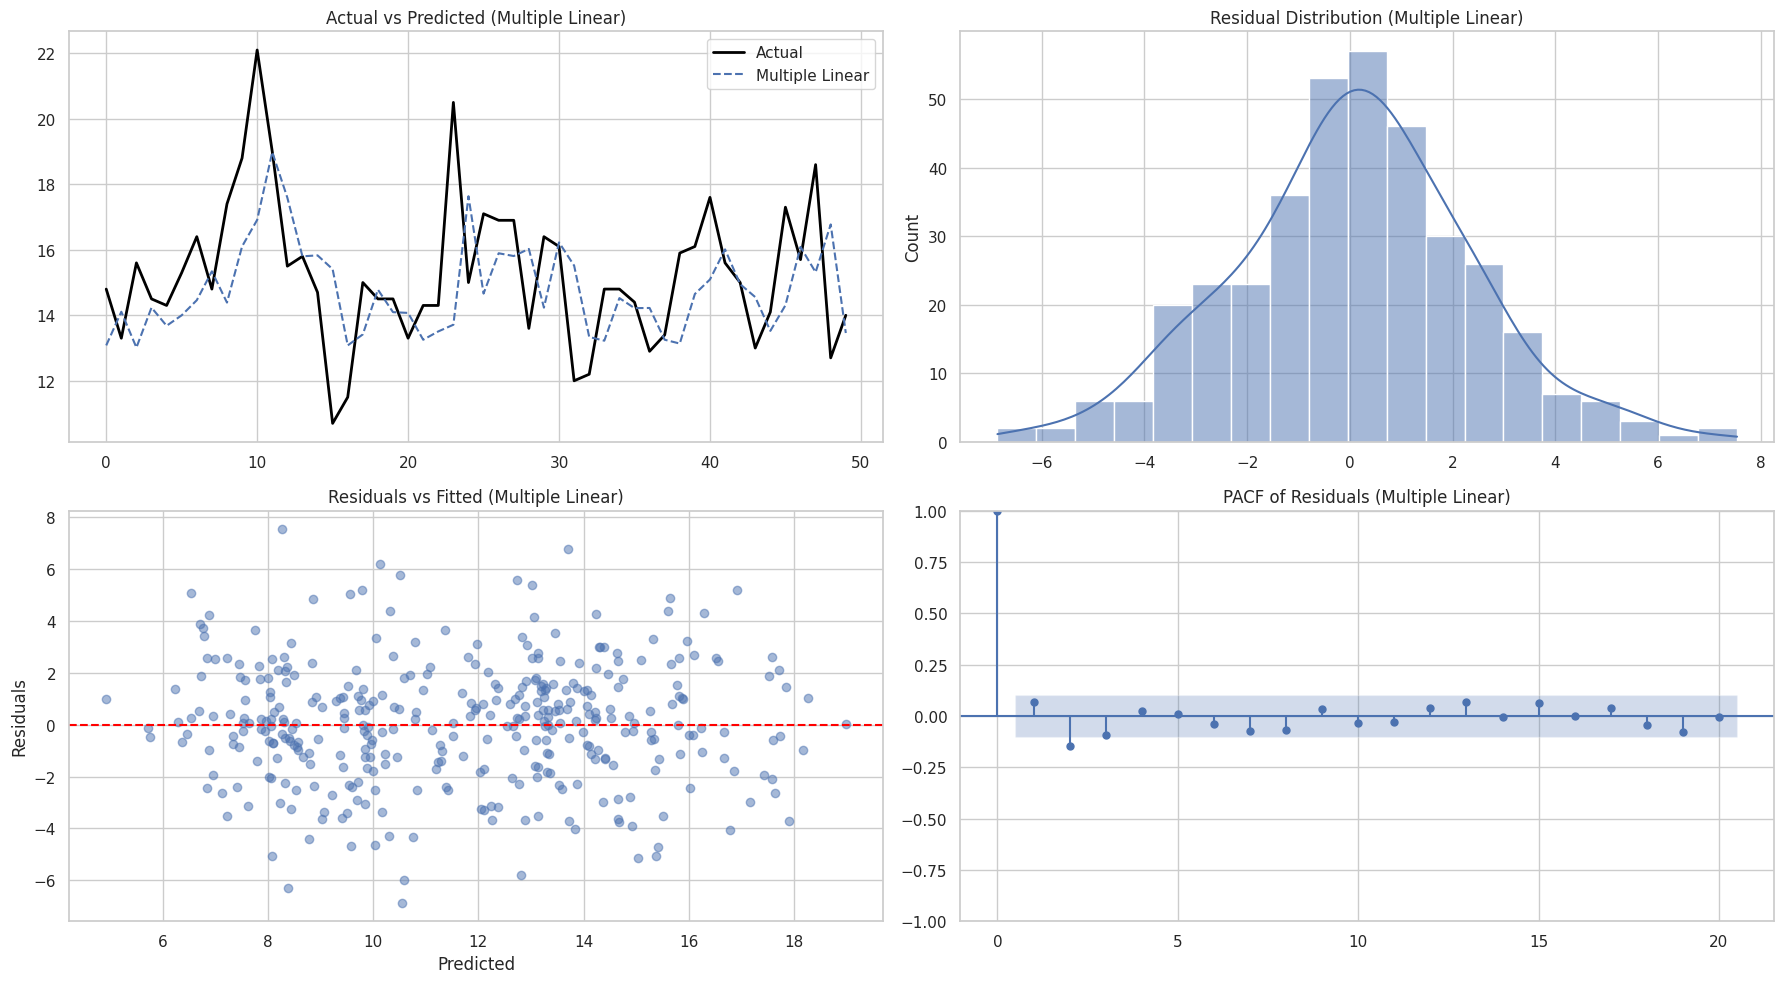



VISUALIZING MODEL: Polynomial




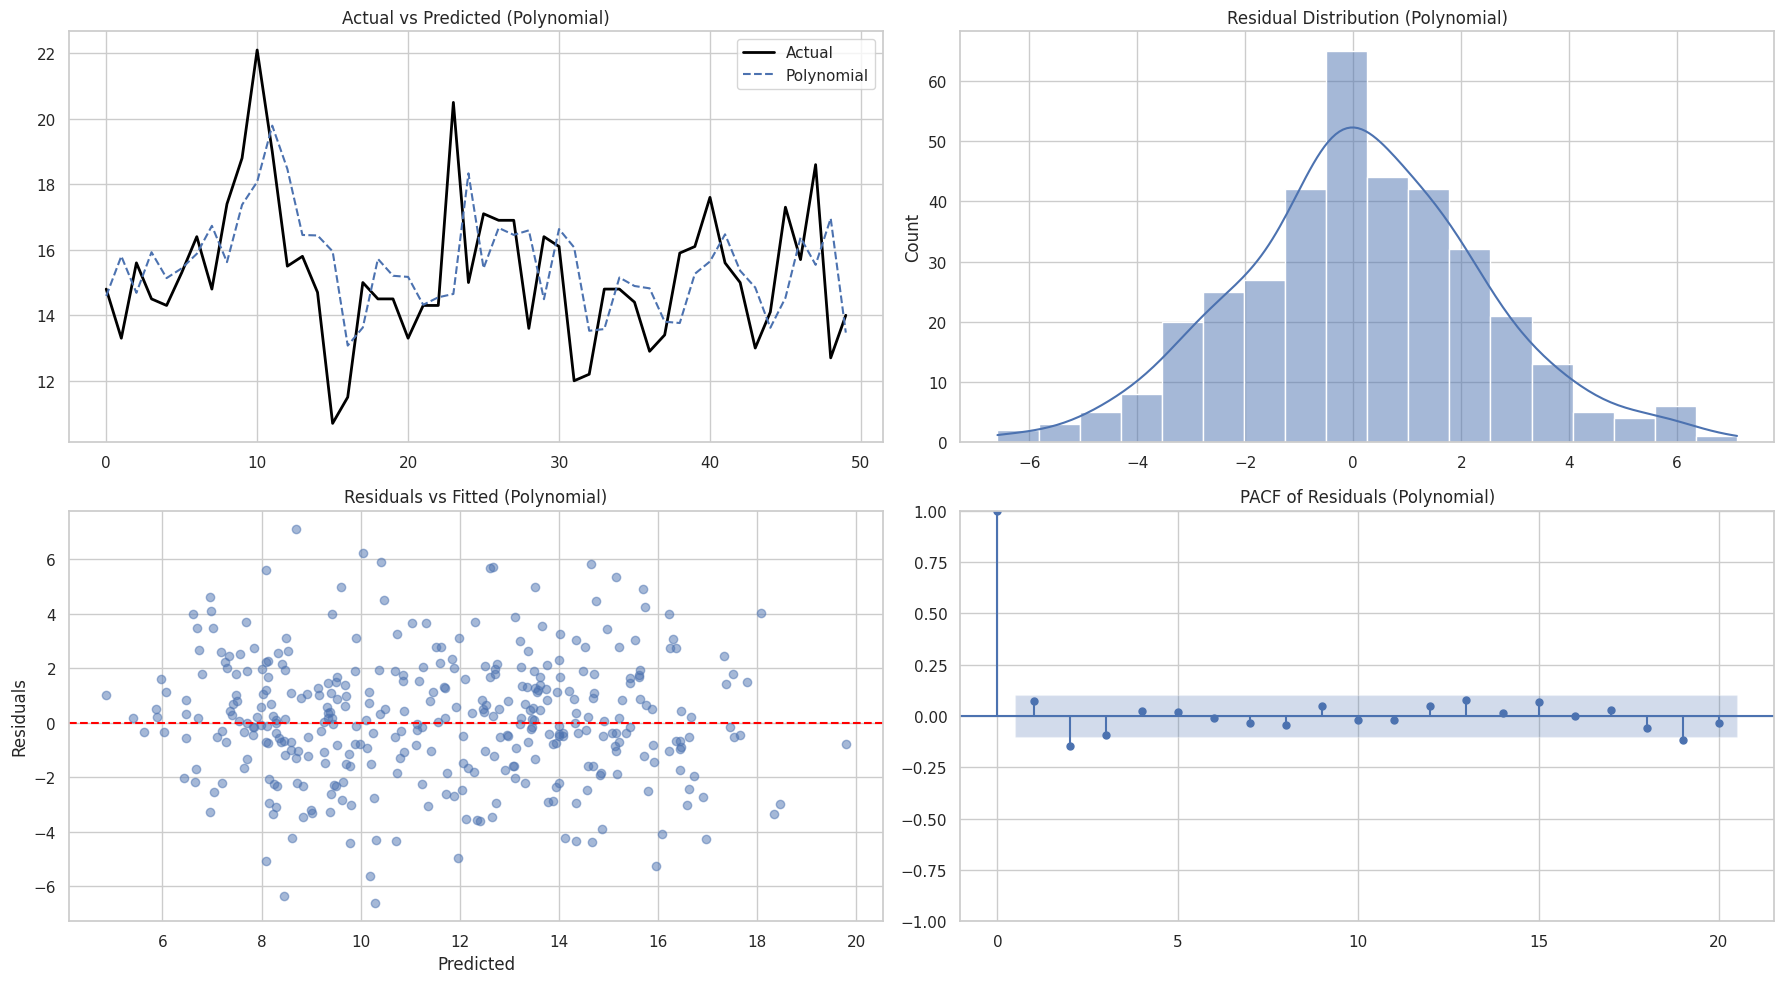



VISUALIZING MODEL: GLM




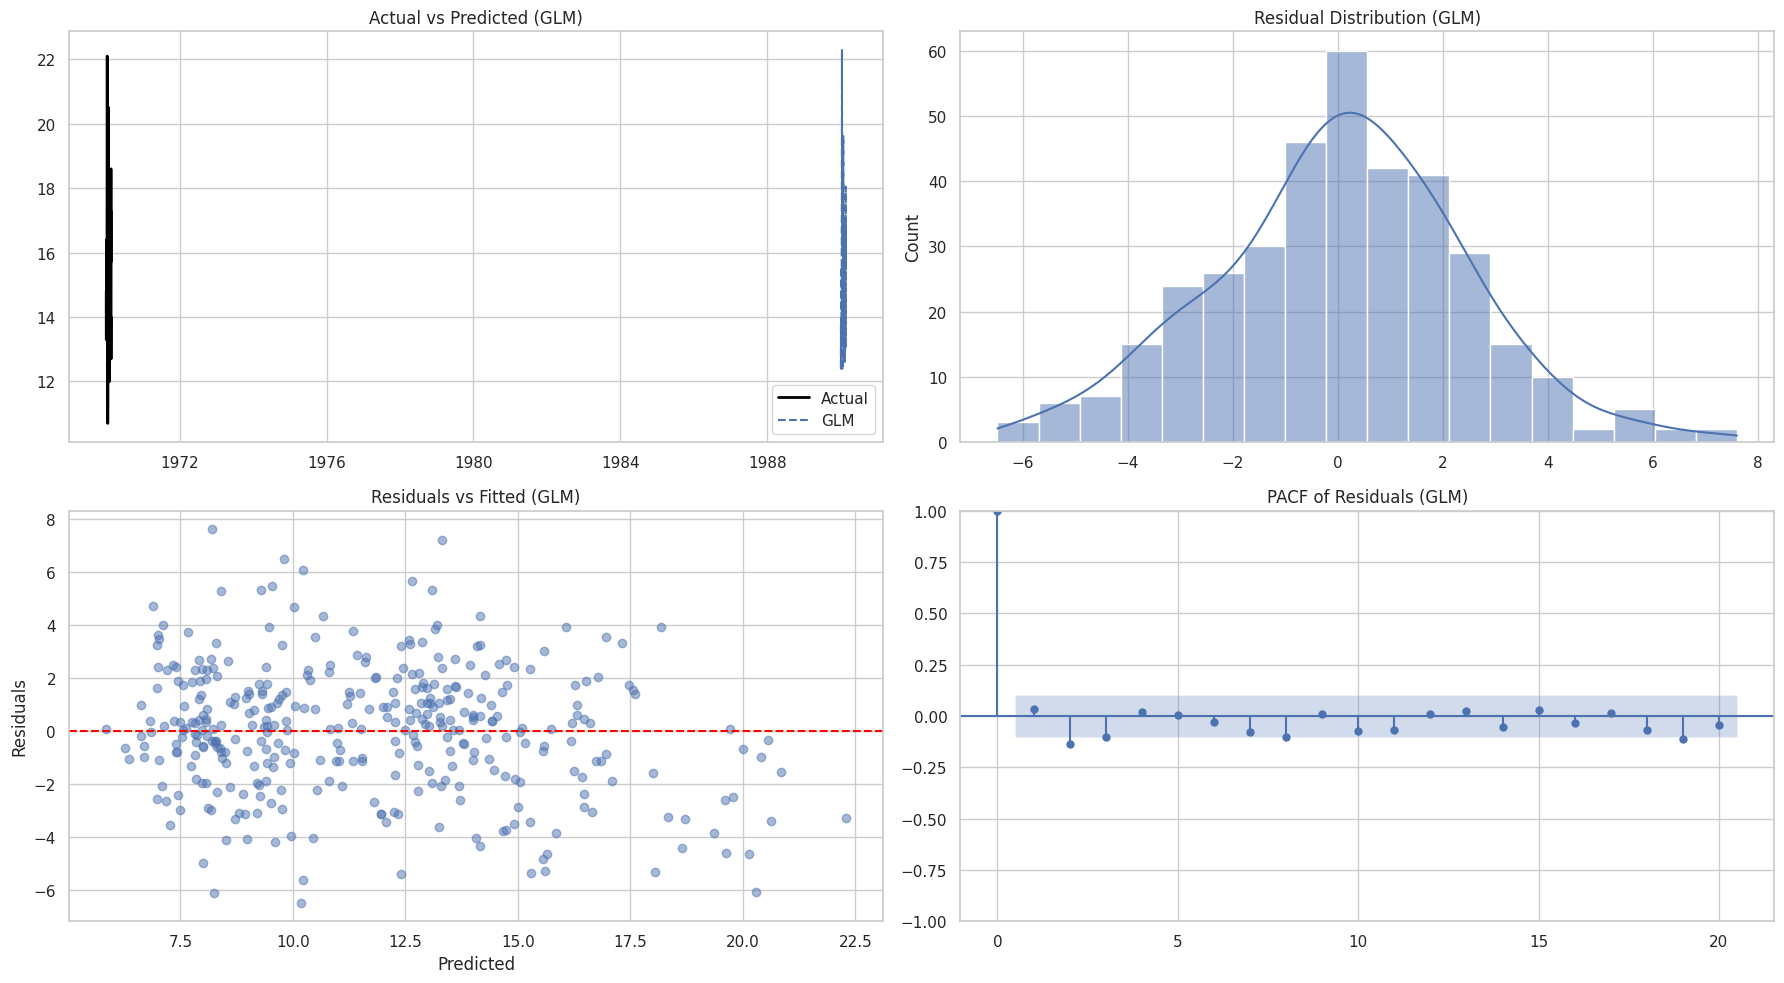



VISUALIZING MODEL: Lasso




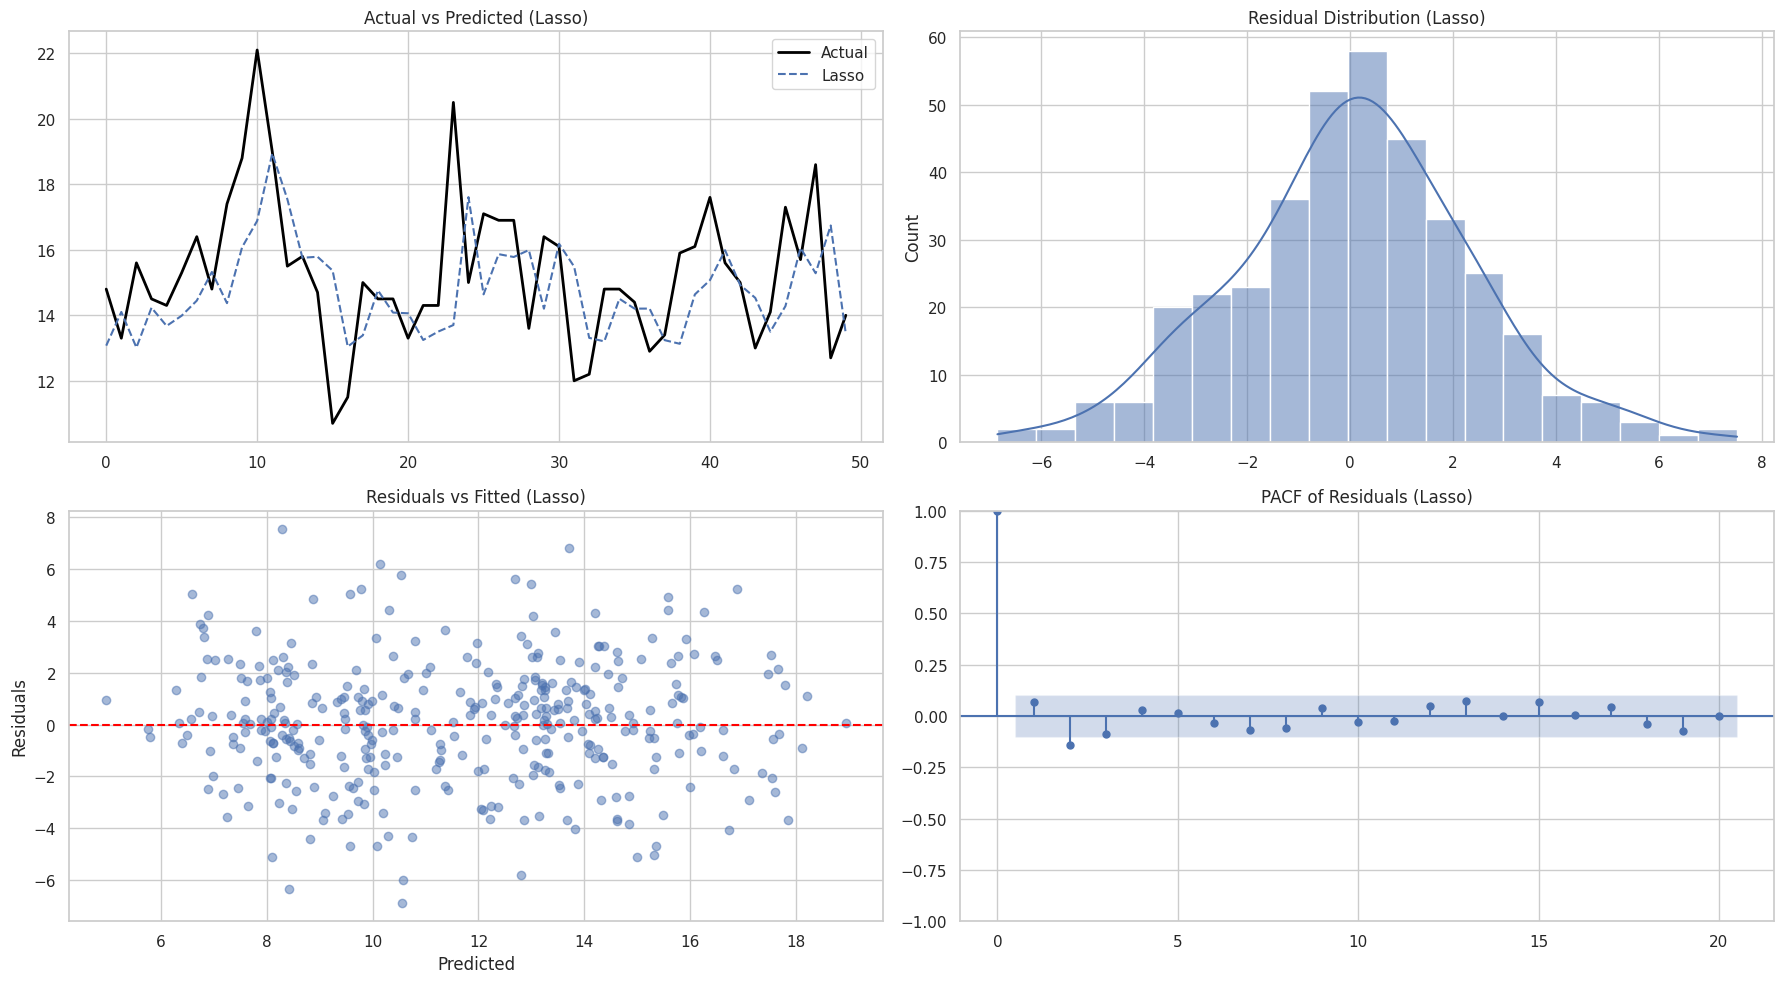



VISUALIZING MODEL: ARIMA




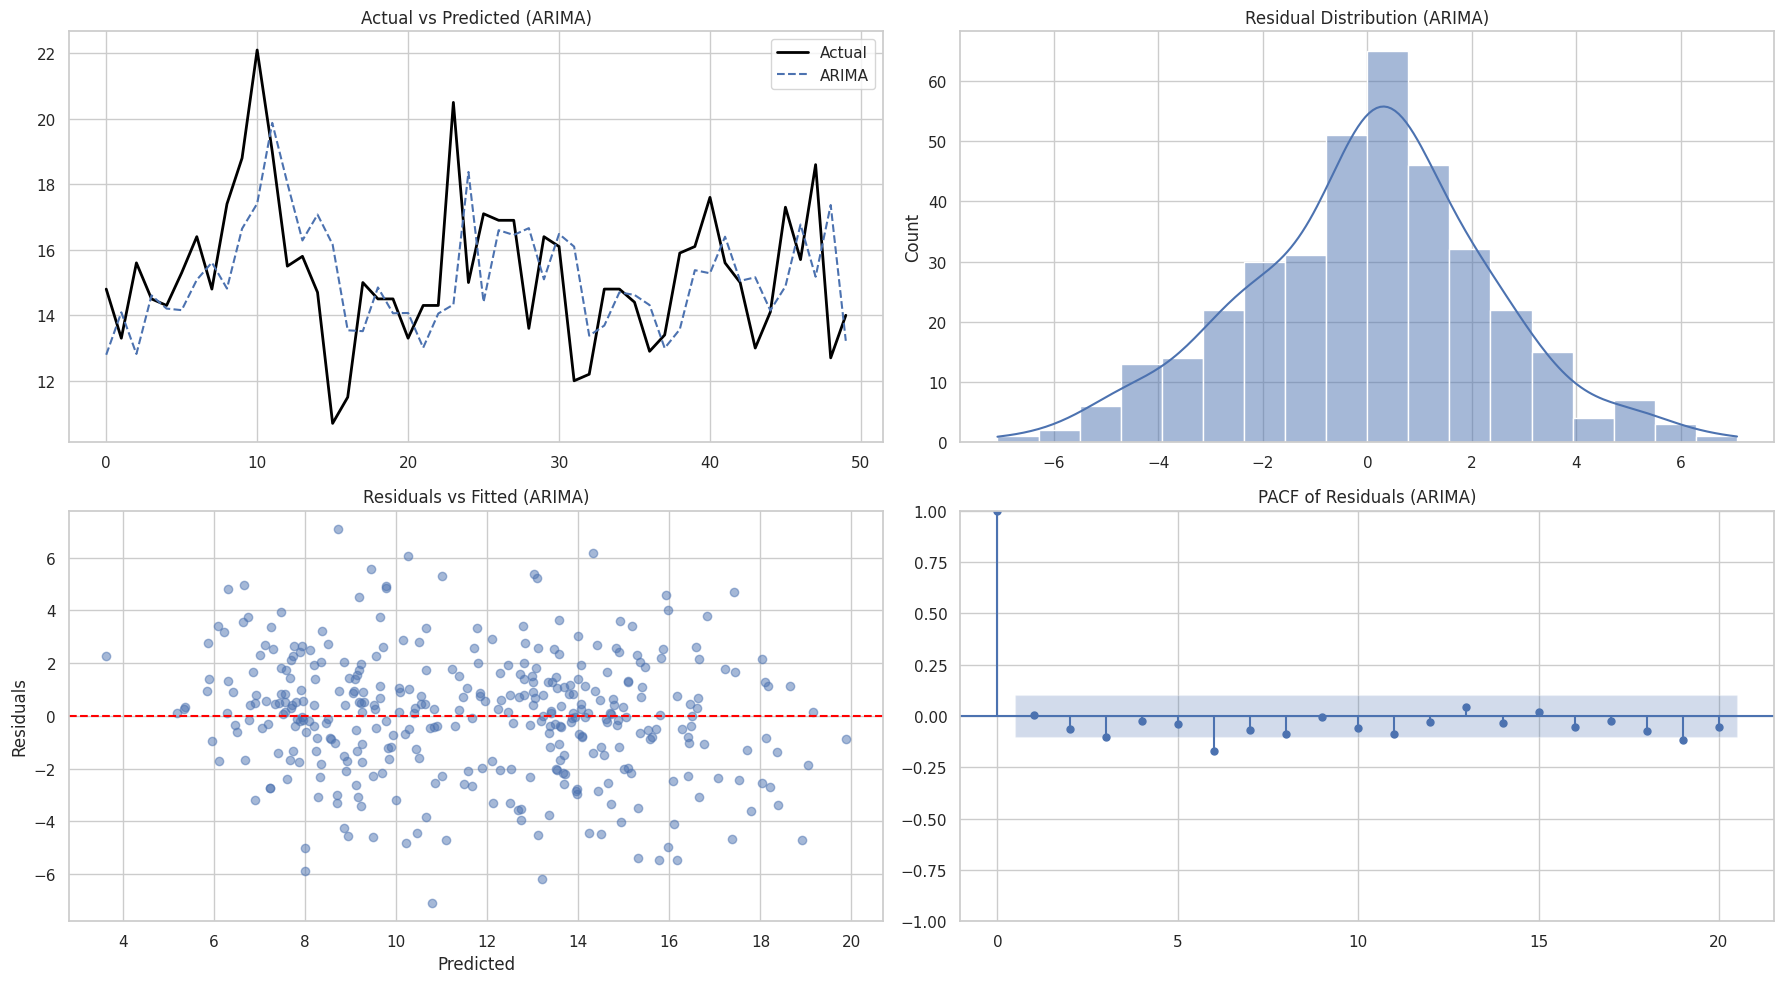



VISUALIZING MODEL: SARIMA




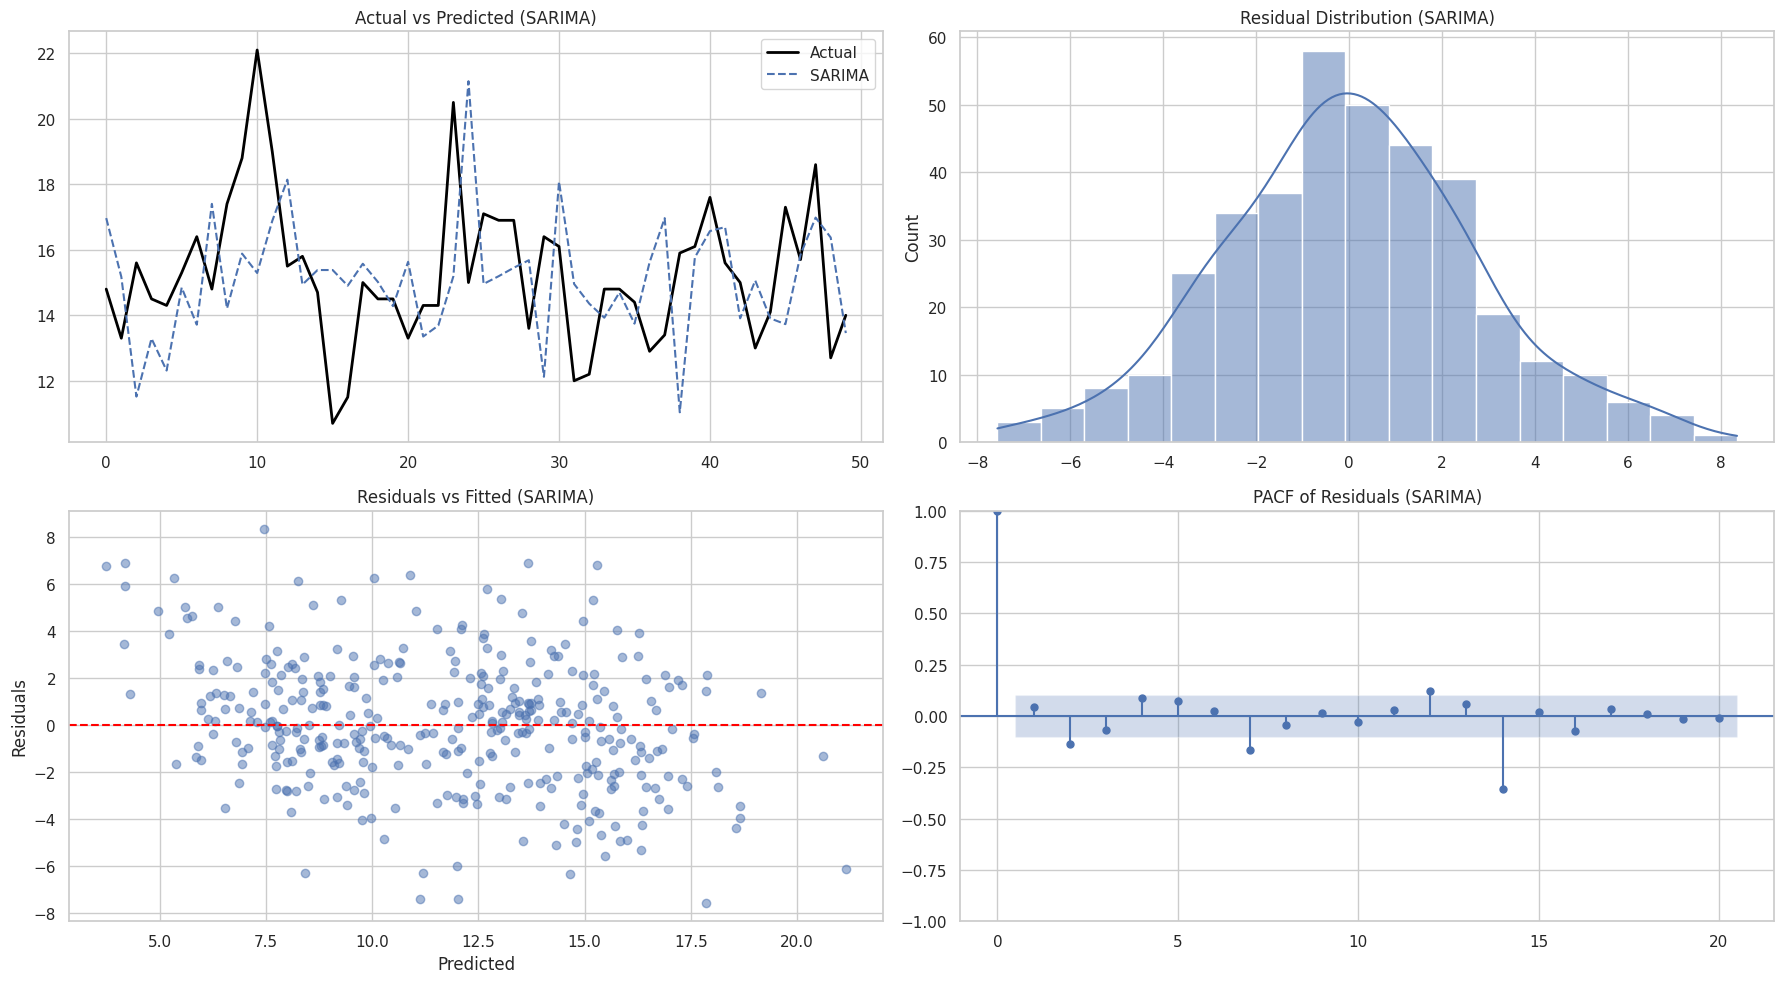

In [ ]:
# INDIVIDUAL MODEL VISUALIZATION

from statsmodels.graphics.tsaplots import plot_pacf

for name, pred in models.items():

    print("\n")
    print(f"VISUALIZING MODEL: {name}")
    print("\n")

    residuals = y_test.values - pred

    plt.figure(figsize=(18, 10))

    #  Actual vs Predicted
    plt.subplot(2, 2, 1)
    plt.plot(y_test.values[:50], label='Actual', color='black', lw=2)
    plt.plot(pred[:50], label=f'{name}', linestyle='--')
    plt.title(f"Actual vs Predicted ({name})")
    plt.legend()


    #  Residual Distribution
    plt.subplot(2, 2, 2)
    sns.histplot(residuals, kde=True)
    plt.title(f"Residual Distribution ({name})")


    #  Residuals vs Fitted
    plt.subplot(2, 2, 3)
    plt.scatter(pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residuals vs Fitted ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")


    #  PACF (Error Randomness)
    plt.subplot(2, 2, 4)
    plot_pacf(residuals, ax=plt.gca(), lags=20)
    plt.title(f"PACF of Residuals ({name})")


    plt.tight_layout()
    plt.show()

In [ ]:
#  CONCLUDING STATEMENTS
adf_p = adfuller(y_train)[1]

print("RTSM PROJECT CONCLUDING POINTS")
print("\n")

print(f"1. STATIONARITY: ADF test p-value = {adf_p:.4f}")
print(f"2. MULTICOLLINEARITY: Max VIF = {vif_data['VIF'].max():.2f}")

print(f"3. PERFORMANCE: '{best_model_name}' is best (RMSE: {df_results.iloc[0]['RMSE']:.4f})")

print("4. DIAGNOSTICS: Residuals show near-random distribution → good model fit")

print(f"5. RECOMMENDATION: Use '{best_model_name}' for short-term forecasting")

print("\n")


RTSM PROJECT CONCLUDING POINTS


1. STATIONARITY: ADF test p-value = 0.0005
2. MULTICOLLINEARITY: Max VIF = 21.25
3. PERFORMANCE: 'Polynomial' is best (RMSE: 2.2787)
4. DIAGNOSTICS: Residuals show near-random distribution → good model fit
5. RECOMMENDATION: Use 'Polynomial' for short-term forecasting




## Stability plot and Executive Summary

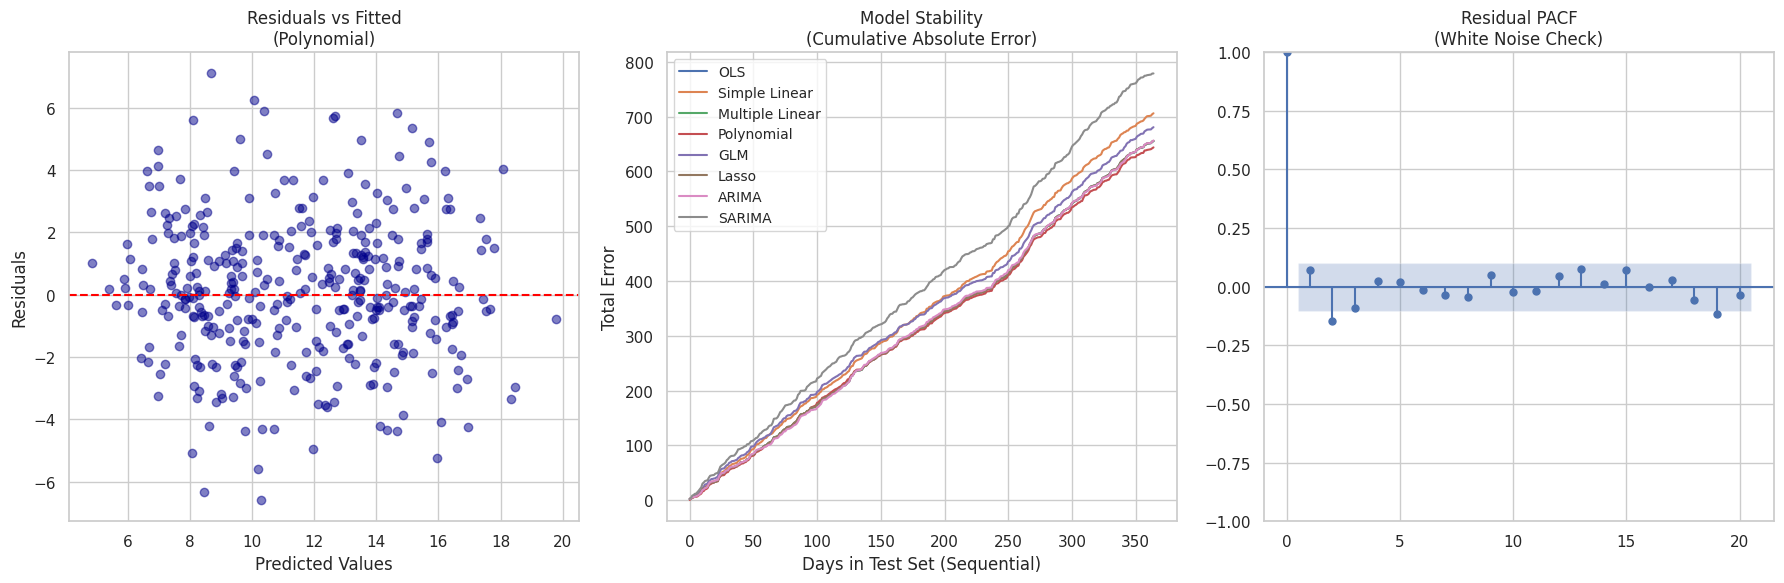



FINAL RTSM PERFORMANCE TABLE


 Rank           Model     RMSE      MAE
    1      Polynomial 2.278669 1.764412
    2             OLS 2.323105 1.795852
    3 Multiple Linear 2.323105 1.795852
    4           Lasso 2.323327 1.796994
    5           ARIMA 2.336087 1.798869
    6             GLM 2.395642 1.865575
    7   Simple Linear 2.436789 1.935153
    8          SARIMA 2.734866 2.134342


BEST MODEL: Polynomial




In [ ]:
# STABILITY PLOT & EXECUTIVE SUMMARY
plt.figure(figsize=(18, 6))

# 1. Residuals vs Fitted
plt.subplot(1, 3, 1)
plt.scatter(models[best_model_name], best_residuals, alpha=0.5, color='darkblue')
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Residuals vs Fitted\n({best_model_name})")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. FIXED Cumulative Absolute Error (Using Integer Index)
plt.subplot(1, 3, 2)
for name, pred in models.items():
    # We use .reset_index() or just range() to avoid the Date-axis bug
    cum_error = np.cumsum(np.abs(y_test.values - pred))
    plt.plot(range(len(cum_error)), cum_error, label=name)
plt.title("Model Stability\n(Cumulative Absolute Error)")
plt.xlabel("Days in Test Set (Sequential)")
plt.ylabel("Total Error")
plt.legend(fontsize='small')

# 3. PACF
plt.subplot(1, 3, 3)
plot_pacf(best_residuals, ax=plt.gca(), lags=20)
plt.title("Residual PACF\n(White Noise Check)")

plt.tight_layout()
plt.show()

# --- THE FINAL TABLE FOR YOUR PDF ---
print("\n")
print("FINAL RTSM PERFORMANCE TABLE")
print("\n")
# Adding a 'Rank' column for clarity
df_results['Rank'] = range(1, len(df_results) + 1)
print(df_results[['Rank', 'Model', 'RMSE', 'MAE']].to_string(index=False))
print("\n")
print(f"BEST MODEL: {best_model_name}")
print("\n")
